# Notebook 01 — PPO baseline, for any configured environment

One knob picks the environment; everything else lives in `config/envs/*.yaml`.
Nothing in this notebook is environment-specific, so the same cells run
MountainCar, Taxi, and every rung of the DoorKey curriculum.

**The curriculum.** `doorkey5x5` → `doorkey6x6` → `doorkey8x8`. Run them in that
order: rungs 2 and 3 warm-start from the previous rung's final checkpoint
(`run.init_from` in the YAML), and warm-starting from a policy that did not
learn is just a slower random initialisation.

**Why a curriculum at all.** DoorKey-8x8 with random layouts asks PPO to
generalise across layouts before it has seen a single reward. Measured: 3M
frames, success never left the 2.1% uniform-random rate, `mean_length` pinned at
the 640-step limit, `v_loss` → 1e-19 and explained variance → exactly 0. The
critic had correctly learned that V = 0 everywhere, so there was no gradient to
tune. Nothing in NB02–06 needs generalisation across layouts.

**To tune anything**, edit the YAML for that environment, or put the change in
`OVERRIDES` below. See `TUNING.md` for what to turn and in what order.

---
## ▶ Knobs

In [1]:
# ----------------------------------------------------------------------------
# EDIT ME
# ----------------------------------------------------------------------------
ENV_CONFIG    = "doorkey8x8"     # a file stem in config/envs/  (see the list below)
FORCE_RETRAIN = True            # recompute even if runs/ already has this run

# Anything here overrides the YAML, using dotted keys. Leave empty to run the
# configuration exactly as committed -- which is what makes a result traceable.
# OVERRIDES = {
#     # "ppo.total_timesteps": 200_000,     # a smoke test before the full run
#     "ppo.ent_coef": 0.1,
#     # "env.layout_seeds": [0, 1, 2, 3],   # fix the layout pool
#     # "run.run_name": "doorkey5x5_ent02",
# }

# OVERRIDES = {
#     "ppo.n_steps": 512,          # 640-step episodes now mostly fit in one rollout
#     "ppo.gamma": 0.995,          # 0.995^355 = 0.17, vs 0.028
#     "ppo.gae_lambda": 0.98,      # effective horizon 17 -> 48 steps
#     "ppo.ent_coef": 0.005,
#     # "ppo.total_timesteps": 1_500_000,
#     "run.run_name": "dk8_horizon",
# }

OVERRIDES = {
    "ppo.n_steps": 512,           # 128 -> 512
    "ppo.n_minibatches": 8,       # keeps minibatch at 1024
    "ppo.n_epochs": 10,           # 4 -> 10
    "ppo.learning_rate": 2.5e-4,  # 1e-3 -> 2.5e-4
    "ppo.ent_coef": 0.003,        # 0.01 -> 0.003
    "ppo.total_timesteps": 3_000_000,
    "run.run_name": "dk8_horizon",
}
# ----------------------------------------------------------------------------

## 0. Setup

In [2]:
# Reload edited modules automatically. Note this still cannot add a field to
# an already-imported dataclass -- for config schema changes, restart the kernel.
%load_ext autoreload
%autoreload 2

import sys, pathlib, time

ROOT = pathlib.Path.cwd()
if not (ROOT / "config").is_dir():          # launched from notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import make_config, list_env_configs, RUNS_DIR, FIGURES_DIR, seed_dir
from dataio import load_trajectories, validate, load_checkpoint, list_checkpoints
from envs.env_pool import make_env
from utils.logging import read_scalars
from utils.plotting import (
    plot_learning_curves, plot_episode_returns, plot_grid,
    plot_subgoal_ladder, plot_signal_diagnostics,
    plot_minigrid_progress, plot_action_usage, plot_minigrid_visitation,
    savefig,
)

print("project root:", ROOT)
print("configured environments:", sorted(list_env_configs()))

project root: /Users/charithapalika/Desktop/Personal Projects/PPO_CF
configured environments: ['doorkey5x5', 'doorkey5x5_cf', 'doorkey6x6', 'doorkey6x6_cf', 'doorkey8x8', 'doorkey8x8_cf', 'mountaincar', 'taxi']


## 1. Configuration

In [3]:
cfg = make_config(ENV_CONFIG, **OVERRIDES)
RUN_NAME  = cfg.run.run_name
SEEDS     = tuple(cfg.run.seeds)
IS_MINIGRID = cfg.env.env_id.startswith("MiniGrid")

FIG = FIGURES_DIR / f"nb01_{RUN_NAME}"
FIG.mkdir(parents=True, exist_ok=True)

print(cfg.summary())

if IS_MINIGRID:
    from envs.minigrid_env import ACTION_NAMES
    print("\nactions:", ACTION_NAMES)
else:
    ACTION_NAMES = [str(i) for i in range(make_env(cfg.env.env_id).action_space.n)]

# Order-of-magnitude only; measured ~1,700 steps/s for the MiniGrid CNN config
# on the reference machine.
est = cfg.ppo.total_timesteps / 1700 / 60
print(f"\nrough runtime      ~{est:.0f} min/seed  ({est * len(SEEDS):.0f} min total)")

config             doorkey8x8
env                MiniGrid-DoorKey-8x8-v0  (n_envs=16, obs_norm=image)
layouts            random every episode
total_timesteps    3,000,000  per seed
rollout batch      8192  (16 envs x 512 steps)
updates            366
minibatch size     1024  x 10 epochs
gamma / lambda     0.99 / 0.95
lr                 0.00025  (anneal=False)
encoder            cnn  (shared=True)
entropy            fixed, coef 0.003
prob floor         0.0 -> 0.0  (0 = off)
adv norm           batch  (min_std 1e-06)
policy gradient    gae
reward shaping     off
warm start         none
seeds              [0]
checkpoints at     ['10%', '30%', '50%', '75%', '100%']

actions: ['0 turn left', '1 turn right', '2 forward', '3 pickup', '4 drop', '5 toggle', '6 done']

rough runtime      ~29 min/seed  (29 min total)


## 2. Train

`run_seeds` writes, per seed, into `runs/<run_name>/seed_<n>/`:
`trajectories.npz`, `checkpoints/ckpt_{010,030,050,075,100}.pt`, `scalars.csv`,
`episodes.csv`, and `runs/<run_name>/config.json` — the exact configuration
used, so any result can be traced back to what produced it.

The same run from the shell, with no notebook involved:

```bash
python -m scripts.train --env doorkey5x5
python -m scripts.train --env doorkey5x5 --frames 200000 --run-name smoke5x5
python -m scripts.train --env doorkey8x8 --set ppo.ent_coef=0.02 env.layout_seeds=[0,1,2,3]
```

In [4]:
from scripts.train import run_seeds

already = all((seed_dir(RUN_NAME, s) / "scalars.csv").exists() for s in SEEDS)

if already and not FORCE_RETRAIN:
    print(f"found existing run at {RUNS_DIR / RUN_NAME} — skipping training")
    print("set FORCE_RETRAIN = True to re-run")
    results = None
else:
    t0 = time.time()
    results = run_seeds(cfg)
    print(f"\ntotal wall time: {(time.time() - t0) / 60:.1f} min")


=== seed 0 ====================================================


/opt/homebrew/anaconda3/envs/workbench/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


  upd    10/366  step   81,920  ret   0.014  succ 0.04  key 0.88 door 0.22  ent 1.901  advstd 1.67e-02  ev -0.081  880 sps
  upd    20/366  step  163,840  ret   0.002  succ 0.01  key 0.82 door 0.14  ent 1.762  advstd 1.51e-02  ev  0.012  875 sps
  upd    30/366  step  245,760  ret   0.004  succ 0.01  key 0.79 door 0.18  ent 1.658  advstd 1.68e-02  ev  0.253  876 sps
  upd    40/366  step  327,680  ret   0.000  succ 0.00  key 0.63 door 0.17  ent 1.631  advstd 1.42e-02  ev  0.596  873 sps
  upd    50/366  step  409,600  ret   0.001  succ 0.01  key 0.66 door 0.16  ent 1.713  advstd 1.27e-02  ev  0.566  860 sps
  upd    60/366  step  491,520  ret   0.004  succ 0.01  key 0.78 door 0.19  ent 1.656  advstd 1.09e-02  ev  0.719  863 sps
  upd    70/366  step  573,440  ret   0.000  succ 0.00  key 0.64 door 0.18  ent 1.621  advstd 1.19e-02  ev  0.524  866 sps
  upd    80/366  step  655,360  ret   0.000  succ 0.00  key 0.65 door 0.04  ent 1.629  advstd 1.03e-02  ev  0.651  869 sps
  upd    90/366 

## 3. Load everything back

In [5]:
scalars  = {s: read_scalars(seed_dir(RUN_NAME, s) / "scalars.csv") for s in SEEDS}
episodes = {s: pd.read_csv(seed_dir(RUN_NAME, s) / "episodes.csv")  for s in SEEDS}
trajs    = ({s: load_trajectories(seed_dir(RUN_NAME, s) / "trajectories.npz") for s in SEEDS}
            if cfg.run.record_trajectories else {})

S0 = SEEDS[0]
summary = pd.DataFrame({
    "first_success_step": {s: (int(e.loc[e["success"], "global_step"].iloc[0])
                               if e["success"].any() else None) for s, e in episodes.items()},
    "episodes":           {s: len(e) for s, e in episodes.items()},
    "total_successes":    {s: int(e["success"].sum()) for s, e in episodes.items()},
    "final_success_100":  {s: d["success_rate_100"].iloc[-1] for s, d in scalars.items()},
    "final_return_100":   {s: d["mean_return_100"].iloc[-1] for s, d in scalars.items()},
    "final_entropy":      {s: d["entropy"].iloc[-1] for s, d in scalars.items()},
    "final_expl_var":     {s: d["explained_variance"].iloc[-1] for s, d in scalars.items()},
    "traj_rows":          {s: len(t) for s, t in trajs.items()} if trajs else {},
})
summary.index.name = "seed"
summary.round(4)

,first_success_step,episodes,total_successes,final_success_100,final_return_100,final_entropy,final_expl_var,traj_rows
seed,,,,,,,,
0,39872,4813,305,0.36,0.1863,1.5056,0.8545,374784


## 4. Return and success

DoorKey's reward is `1 − 0.9·(steps / max_steps)` on success and `0` otherwise,
so mean return and success rate carry almost the same information — return
additionally rewards *finishing faster*. `max_steps` is `10·size²`: 250 for 5x5,
360 for 6x6, 640 for 8x8. An episode length pinned at that limit means the
episode is always being truncated, i.e. the goal is never reached.

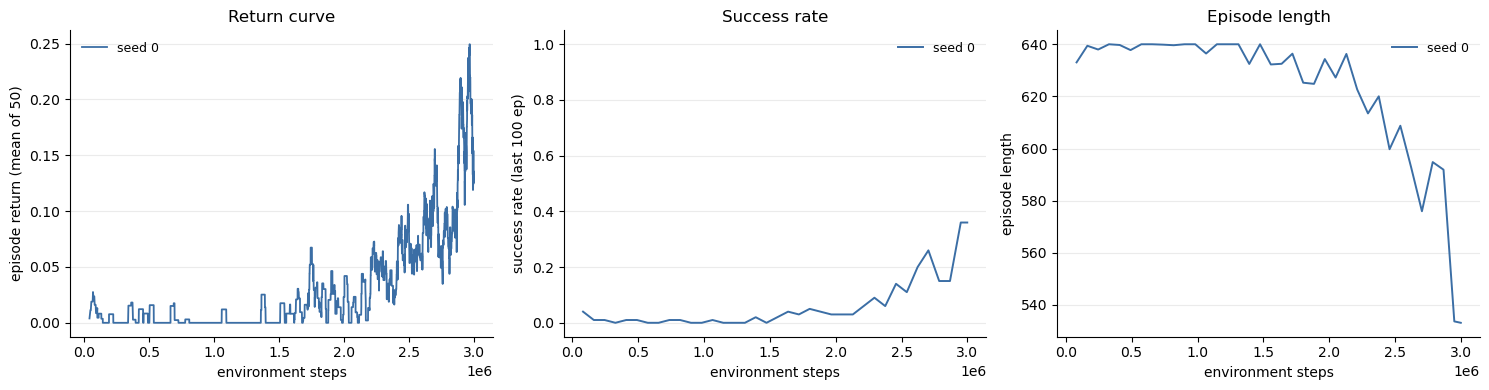

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_episode_returns(episodes, window=50, ax=axes[0])
plot_learning_curves(scalars, y="success_rate_100",
                     ylabel="success rate (last 100 ep)", title="Success rate", ax=axes[1])
axes[1].set_ylim(-0.05, 1.05)
plot_learning_curves(scalars, y="mean_length_100",
                     ylabel="episode length", title="Episode length", ax=axes[2])
fig.tight_layout()
savefig(fig, FIG / "return_and_success.png")
plt.show()

## 5. The sub-goal ladder — the metric that matters on a sparse task

Success rate alone is a poor progress signal: it can sit at exactly zero for
millions of frames while the policy is either improving or dying, and the two
look identical. DoorKey has hard prerequisites — no goal without an open door,
no open door without the key — so the ladder says **which rung** the policy is
stuck on. The rungs need opposite responses:

| what you see | what it means | what to do |
|---|---|---|
| all three flat | no learning signal at all | check `adv_std_raw` below first |
| key rises, door flat | stuck at the door | check `π(toggle)` in §7; consider potential shaping on the door |
| door rises, success flat | stuck between door and goal | usually just undertrained — more frames |
| everything rises then collapses | rare reward averaged away | lower `ent_coef`, or `ent_mode: adaptive` |

This is the panel that diagnosed the failed 8x8 run: key pickup ran at 40–80%
the entire time while solved stayed at ~0. The agent reached the key constantly
and never converted it.

In [ ]:
fig = plot_subgoal_ladder(scalars, labels=("Picked up the key", "Opened the door"))
fig.suptitle(f"{RUN_NAME} — sub-goal ladder", y=1.04, fontsize=11)
savefig(fig, FIG / "subgoal_ladder.png")
plt.show()

if IS_MINIGRID and trajs:
    fig, prog = plot_minigrid_progress(trajs[S0], n_bins=25)
    fig.suptitle(f"seed {S0} — per-episode sub-goal progress (from trajectories)",
                 y=1.04, fontsize=11)
    savefig(fig, FIG / "subgoal_progress.png")
    plt.show()
    print("Note: with trajectory_stride > 1 these come from a subsample of steps,")
    print("so a key pickup can occasionally be missed. scalars.csv is exact.")

## 6. Was there a signal at all?

`adv_std_raw` is the spread of the advantages **before** whitening. It separates
the two situations every other diagnostic confounds: *learning slowly* versus
*receiving nothing to learn from*.

If it sits at the `norm_adv_min_std` floor (1e-6), the rollout carried no
signal, and any movement in entropy, `approx_kl` or `clipfrac` during that
stretch is numerical noise — not exploration. The 3M DoorKey-8x8 run held
`clipfrac` at 0.05–0.18 while `v_loss` was 1e-19: every one of those updates was
the policy being random-walked by rescaled float error, which is exactly what
`PPOTrainer._normalise` now refuses to do.

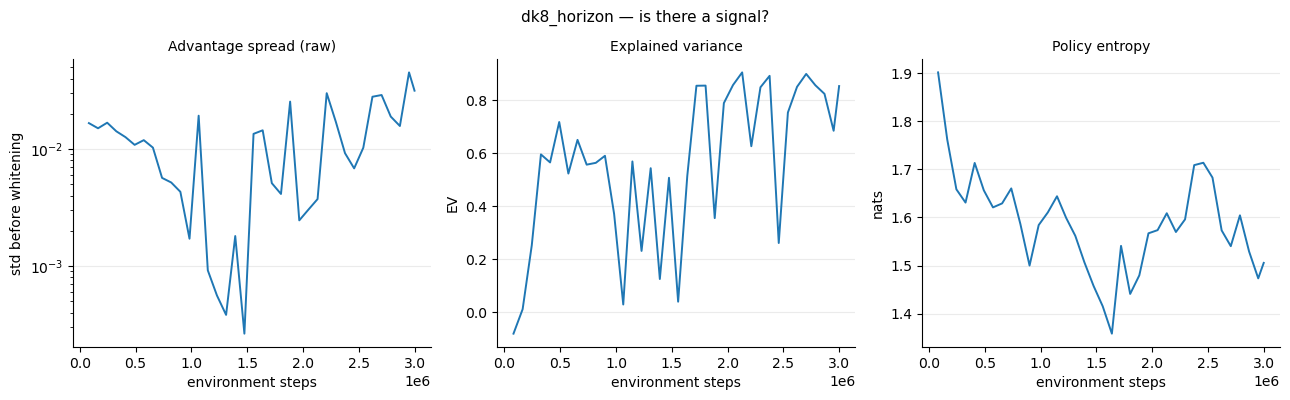

  seed 0: 0.0% of logged updates had effectively no advantage signal


In [8]:
fig = plot_signal_diagnostics(scalars)
fig.suptitle(f"{RUN_NAME} — is there a signal?", y=1.04, fontsize=11)
savefig(fig, FIG / "signal.png")
plt.show()

for s, d in scalars.items():
    frac_dead = float((d["adv_std_raw"] < 10 * cfg.ppo.norm_adv_min_std).mean())
    print(f"  seed {s}: {frac_dead:.1%} of logged updates had effectively no advantage signal")

## 7. Optimisation diagnostics

What to look for:

- **entropy** — starts near log K (log 7 = 1.946 on MiniGrid). Pinned there means
  the policy is committing to nothing; collapsing toward 0 *before* any success
  means the run is dead (how the MountainCar and Taxi attempts failed).
- **explained_variance** — the critic's quality. NB02's oracle is built directly
  on V, so a low value here caps everything downstream.
- **approx_kl / clipfrac** — update size. Read them together with `adv_std_raw`:
  a healthy-looking clipfrac on a zero-signal rollout means nothing.
- **grad_norm_actor vs grad_norm_critic** — logged separately because on
  MountainCar the critic's gradient swamped a single global clip and silently
  froze the policy. Only populated when `separate_grad_clip` is in effect (it is
  disabled automatically when `share_encoder` is on).

no data (expected for the inactive controllers): ['grad_norm_actor']


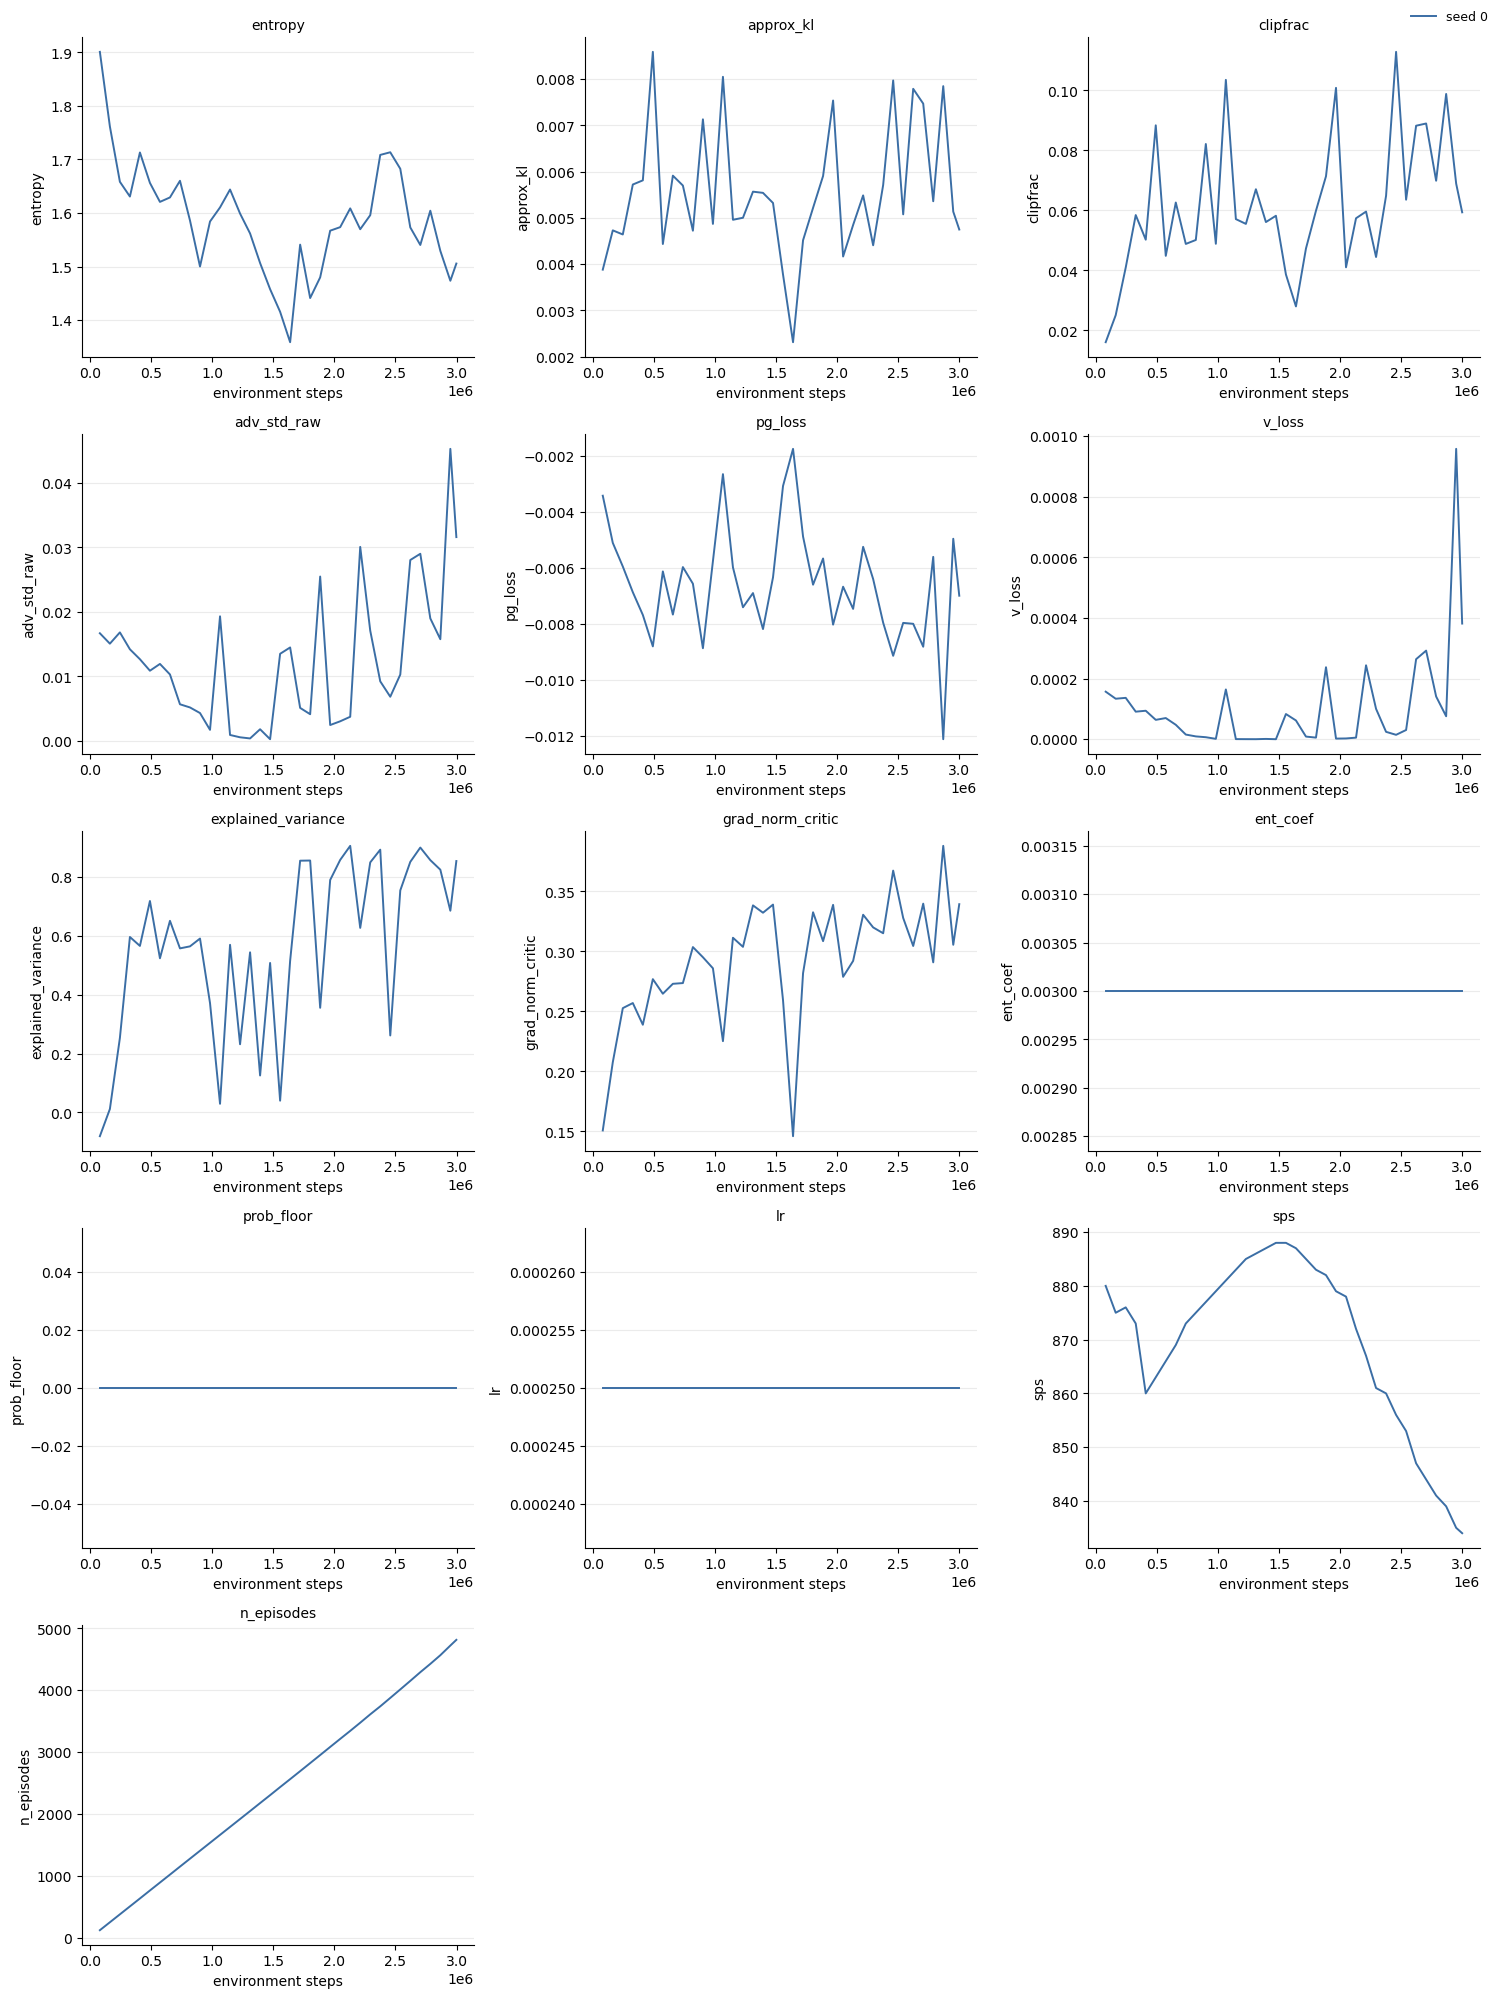

In [9]:
wanted = ["entropy", "approx_kl", "clipfrac", "adv_std_raw",
          "pg_loss", "v_loss", "explained_variance",
          "grad_norm_actor", "grad_norm_critic", "ent_coef", "prob_floor",
          "lr", "sps", "n_episodes"]
keys = [k for k in wanted
        if all(k in d.columns and np.isfinite(d[k]).any() for d in scalars.values())]
skipped = [k for k in wanted if k not in keys]
if skipped:
    print("no data (expected for the inactive controllers):", skipped)

fig = plot_grid(scalars, keys, ncols=3, figsize=(15, 4 * ((len(keys) + 2) // 3)))
savefig(fig, FIG / "diagnostics.png")
plt.show()

## 8. Per-action behaviour

The single most important diagnostic learned from the Taxi attempt. There the
policy drove `π(PICKUP)` to 0.0016 and `π(DROPOFF)` below 0.007 — making success
impossible — while total entropy still read a healthy 1.23 of log 6. **Every
aggregate metric looked fine.** Entropy is maximised just as well by spreading
mass over the movement actions, so only a per-action view reveals it.

DoorKey has the same structure: `pickup` (3) and `toggle` (5) are mandatory,
`drop` (4) and `done` (6) are useless. If pickup or toggle decays toward zero the
run cannot succeed no matter how long it trains, and entropy alone cannot fix it
— that is what `ppo.prob_floor_start` is for.

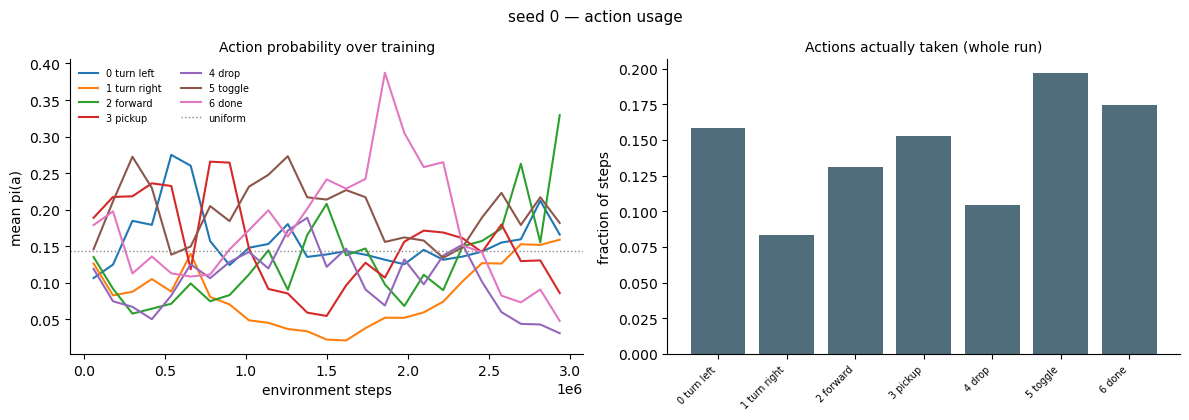

mean pi(a) over the whole run, and the minimum reached in any 5% window:
  0 turn left    mean 0.1580   min-window 0.1054
  1 turn right   mean 0.0832   min-window 0.0207
  2 forward      mean 0.1310   min-window 0.0540
  3 pickup       mean 0.1533   min-window 0.0620
  4 drop         mean 0.1040   min-window 0.0326
  5 toggle       mean 0.1964   min-window 0.1402
  6 done         mean 0.1741   min-window 0.0554


In [10]:
if trajs:
    fig = plot_action_usage(trajs[S0], ACTION_NAMES, n_bins=25)
    fig.suptitle(f"seed {S0} — action usage", y=1.04, fontsize=11)
    savefig(fig, FIG / "action_usage.png")
    plt.show()

    p = trajs[S0].probs
    step = trajs[S0].global_step.astype(float)
    edges = np.linspace(step.min(), step.max() + 1, 21)
    w = np.clip(np.digitize(step, edges) - 1, 0, 19)
    print("mean pi(a) over the whole run, and the minimum reached in any 5% window:")
    for a, name in enumerate(ACTION_NAMES):
        per_win = np.array([p[w == b, a].mean() if (w == b).any() else np.nan for b in range(20)])
        flag = "   <-- effectively unused" if np.nanmin(per_win) < 0.01 else ""
        print(f"  {name:14s} mean {p[:, a].mean():.4f}   min-window {np.nanmin(per_win):.4f}{flag}")
else:
    print("no trajectories recorded (run.record_trajectories = False)")

## 9. State visitation

Where the agent actually goes, split by whether it is carrying the key. In
DoorKey the grid is two rooms separated by a locked door; a policy that has
learned the task should show clear mass in the far room **only** in the
"carrying the key" panel.

This also matters for NB02: the oracle's evaluation states must come from a
region the policy actually visits.

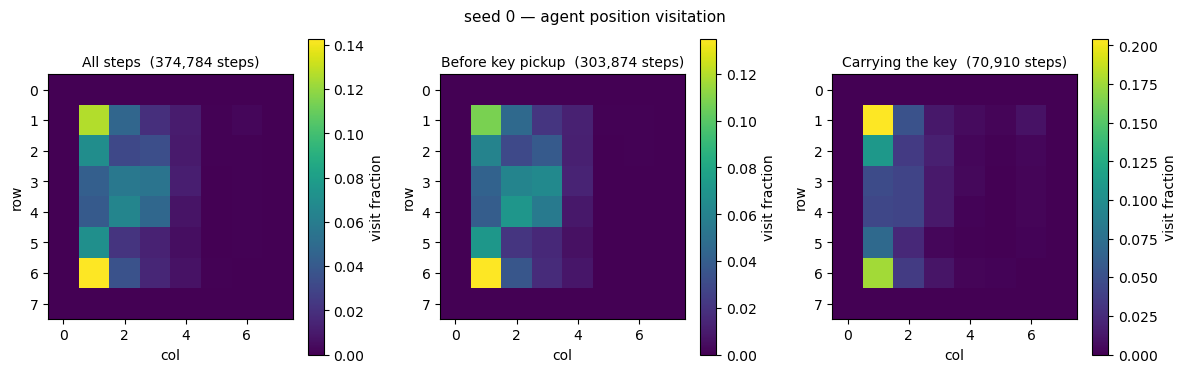

In [11]:
if IS_MINIGRID and trajs:
    fig = plot_minigrid_visitation(trajs[S0])      # grid size inferred from sim_state
    fig.suptitle(f"seed {S0} — agent position visitation", y=1.04, fontsize=11)
    savefig(fig, FIG / "state_visitation.png")
    plt.show()

## 10. CHECK — checkpoints reload, and the policy actually learned

Two checks at once. A `Checkpoint` bundles the network **and** the observation
scaler, because the scaler sits between a simulator state and the network input;
saving one without the other is the classic silent-corruption bug in this kind of
pipeline. And greedy rollouts measure whether anything was learned, separately
from the stochastic training policy.

Evaluation seeds start at 900,000 so they never collide with training layouts —
if `env.layout_seeds` is set, this is therefore a *generalisation* test and will
read lower than training success by design.

In [12]:
def greedy_eval(ck, n_episodes=50, seed0=900_000):
    env = make_env(cfg.env.env_id, cfg.env.max_episode_steps,
                   **({"fully_observable": cfg.env.fully_observable} if IS_MINIGRID else {}))
    rets, succ, lens = [], 0, []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed0 + ep)
        total, t = 0.0, 0
        while True:
            a = int(np.argmax(ck.probs(np.asarray(obs).ravel()[None, :])[0]))
            obs, r, term, trunc, _ = env.step(a)
            total += r; t += 1
            if term:
                succ += 1; break
            if trunc:
                break
        rets.append(total); lens.append(t)
    env.close()
    return float(np.mean(rets)), succ / n_episodes, float(np.mean(lens))


rows = []
for s in SEEDS:
    for p_ in list_checkpoints(seed_dir(RUN_NAME, s) / "checkpoints"):
        ck = load_checkpoint(p_)
        ret, sr, ln = greedy_eval(ck)
        rows.append({"seed": s, "frac": f"{ck.fraction:.0%}", "step": ck.global_step,
                     "greedy_return": round(ret, 4), "greedy_success": sr,
                     "greedy_length": round(ln, 1)})

FRAC_ORDER = [f"{f:.0%}" for f in cfg.run.checkpoint_fractions]
evaldf = pd.DataFrame(rows)
evaldf["frac"] = pd.Categorical(evaldf["frac"], categories=FRAC_ORDER, ordered=True)
display(evaldf.pivot(index="seed", columns="frac", values=["greedy_return", "greedy_success"]))
evaldf

greedy_return                     greedy_success                    
frac           10%  30%  50%  75% 100%            10%  30%  50%  75% 100%
seed                                                                     
0              0.0  0.0  0.0  0.0  0.0            0.0  0.0  0.0  0.0  0.0

,seed,frac,step,greedy_return,greedy_success,greedy_length
0,0,10%,303104,0.0,0.0,640.0
1,0,30%,901120,0.0,0.0,640.0
2,0,50%,1507328,0.0,0.0,640.0
3,0,75%,2252800,0.0,0.0,640.0
4,0,100%,2998272,0.0,0.0,640.0


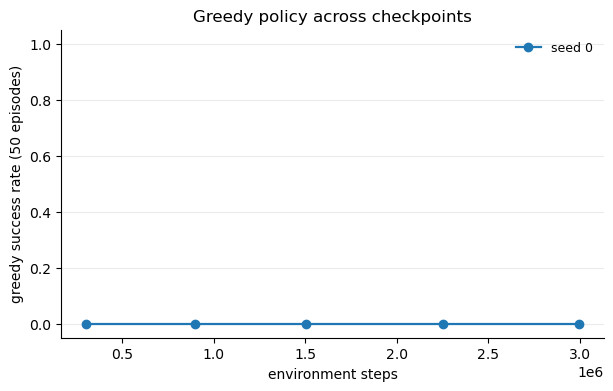

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
for s in SEEDS:
    sub = evaldf[evaldf.seed == s].sort_values("step")
    ax.plot(sub["step"], sub["greedy_success"], marker="o", lw=1.6, label=f"seed {s}")
ax.set_xlabel("environment steps"); ax.set_ylabel("greedy success rate (50 episodes)")
ax.set_title("Greedy policy across checkpoints")
ax.set_ylim(-0.05, 1.05); ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", alpha=0.25)
savefig(fig, FIG / "greedy_checkpoints.png")
plt.show()

## 11. CHECK — trajectory files reload and are structurally sound

`dataio.trajectory.validate` asserts the properties NB02–06 depend on: `probs`
rows sum to 1 and match `logprob`; `next_obs[t] == obs[t+1]` inside an episode
(the recorded successor is the true successor, never a post-reset observation);
no row is both terminated and truncated; everything finite.

With `trajectory_stride > 1` the successor check is skipped for dropped rows, so
it validates the rows that were kept rather than the full stream.

In [14]:
all_clean = True
for s, t in trajs.items():
    p_ = seed_dir(RUN_NAME, s) / "trajectories.npz"
    print(f"seed {s}  ({p_.stat().st_size / 1e6:.1f} MB)")
    problems = validate(t, n_actions=t.n_actions)
    print("  ->", problems if problems else "NO PROBLEMS")
    all_clean &= not problems
    print()
print("TRAJECTORY VALIDATION:", "PASS" if all_clean else "FAIL")

seed 0  (8.3 MB)
  rows            374,784
  episodes        607
  terminated rows 46   (MDP termination = task solved)
  truncated rows  559
  problems        0
  -> NO PROBLEMS

TRAJECTORY VALIDATION: PASS


## 12. Gate 1 verdict

In [15]:
# Uniform-random success, measured. DoorKey-8x8: 42/2000 = 0.021.
RANDOM_BASELINE = {"MiniGrid-DoorKey-8x8-v0": 0.021}.get(cfg.env.env_id, 0.0)

best_greedy = {s: evaldf[evaldf.seed == s]["greedy_success"].max() for s in SEEDS}
mandatory = [3, 5] if IS_MINIGRID else []       # pickup, toggle

checks = {
    "every seed reaches the goal at least once":
        all(episodes[s]["success"].any() for s in SEEDS),
    f"greedy success beats uniform random ({RANDOM_BASELINE:.3f}) at some checkpoint":
        all(best_greedy[s] > RANDOM_BASELINE for s in SEEDS),
    "mandatory actions stay usable (mean pi > 0.01)":
        (not trajs) or all(all(trajs[s].probs[:, a].mean() > 0.01 for a in mandatory)
                           for s in SEEDS),
    # MEDIAN, not the last value. Once the task is solved every episode
    # returns nearly the same thing, so var(returns) -- the DENOMINATOR of
    # explained variance -- collapses and EV becomes a very noisy statistic
    # computed from one 2048-sample rollout. On the 5x5 run EV had median
    # 0.614 with 88% of updates above 0.3, and the single final update read
    # 0.19. Judging the critic on that one number is judging noise.
    "critic is informative (median explained variance > 0.3)":
        all(scalars[s]["explained_variance"].median() > 0.3 for s in SEEDS),
    "the rollouts carried signal (median adv_std_raw > 1e-4)":
        all(scalars[s]["adv_std_raw"].median() > 1e-4 for s in SEEDS),
    "trajectory files reload and validate": all_clean,
    f"{len(cfg.run.checkpoint_fractions)} checkpoints per seed, all reloadable":
        all(len(list_checkpoints(seed_dir(RUN_NAME, s) / "checkpoints"))
            == len(cfg.run.checkpoint_fractions) for s in SEEDS),
}

width = max(len(k) for k in checks)
for k, v in checks.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k:<{width}}")

print()
print("GATE 1:", "PASS — the baseline learns and the dataset is sound"
      if all(checks.values()) else "FAIL — see TUNING.md before proceeding")
print()
for s in SEEDS:
    print(f"  seed {s}: best greedy success {best_greedy[s]:.2f}, "
          f"final training success {scalars[s]['success_rate_100'].iloc[-1]:.2f}")

# The critic's error in the units of the reward, which does not degrade as the
# return variance collapses -- read this alongside EV, not instead of it.
for s in SEEDS:
    ev = scalars[s]["explained_variance"]
    rmse = float(np.sqrt(2 * scalars[s]["v_loss"].iloc[-5:].mean()))
    print(f"  seed {s}: EV median {ev.median():.3f}, {float((ev > 0.3).mean()):.0%} of updates > 0.3, "
          f"final {ev.iloc[-1]:.3f} | value RMSE (last 5 updates) {rmse:.4f}")


  PASS  every seed reaches the goal at least once                     
  FAIL  greedy success beats uniform random (0.021) at some checkpoint
  PASS  mandatory actions stay usable (mean pi > 0.01)                
  PASS  critic is informative (median explained variance > 0.3)       
  PASS  the rollouts carried signal (median adv_std_raw > 1e-4)       
  PASS  trajectory files reload and validate                          
  PASS  5 checkpoints per seed, all reloadable                        

GATE 1: FAIL — see TUNING.md before proceeding

  seed 0: best greedy success 0.00, final training success 0.36
  seed 0: EV median 0.591, 78% of updates > 0.3, final 0.854 | value RMSE (last 5 updates) 0.0272


---

## Where to go next

**If this rung passed**, move up the curriculum: set `ENV_CONFIG` to the next
rung. It warm-starts from this run's `ckpt_100.pt` automatically.

**If it failed**, `TUNING.md` lists the knobs in the order worth trying, each
tied to the diagnostic that justifies it. Do not tune more than one at a time,
and change them in `config/envs/<env>.yaml` (or `OVERRIDES` above) — never in
this notebook, so a result stays traceable to a committed configuration.

## What Notebook 02 inherits

Per seed, in `runs/<run_name>/seed_<n>/`:

| artifact | contents |
|---|---|
| `trajectories.npz` | one row per recorded step; `sim_state` is the packed MiniGrid state (`grid.encode()` + agent col/row/dir + carried object + step count), not the observation |
| `checkpoints/ckpt_*.pt` | weights **and** the frozen observation scaler, at 10/30/50/75/100% |
| `scalars.csv`, `episodes.csv` | diagnostics, including the sub-goal ladder |
| `../config.json` | the exact configuration used |

State restore is exact and verified: over 400 transitions, restoring a packed
`sim_state` into a fresh env and replaying the same action reproduced the state,
reward, termination flag **and** observation with zero mismatches.

```python
from envs.env_pool import make_env, set_sim_state, get_sim_state
env = make_env(cfg.env.env_id, fully_observable=True)
obs = set_sim_state(env, traj.sim_state[i])    # exact restore, wrappers re-applied
```

Two things to settle before running NB02 here:

1. **Which checkpoint the oracle uses.** On MountainCar the plan's ~30% choice
   gave a landscape that was zero to four decimal places, because the critic had
   never seen a reward. Check `explained_variance` and the greedy table above
   before picking.
2. **K = 7 changes the null.** Chance best-action agreement is 1/7 ≈ 0.143, not
   1/3. And `drop` and `done` are useless in DoorKey, so they should appear in
   the landscape as uniformly bad — a useful sanity check on the oracle, and a
   reason not to compute best-action agreement over all seven actions naively.
3. **Reward shaping changes what the oracle measures.** If `reward.potential_shaping`
   was on, the critic learned `V_shaped = V_true − Φ`; add Φ back before building
   the landscape. If a count bonus was on, the checkpoint is not usable for the
   oracle at all — which is why the trainer refuses to save one while the bonus
   is still nonzero.